<a href="https://colab.research.google.com/github/shahidc-cloud/hormuz/blob/main/strait_of_hormuz_shipping_crisis_2026_advanced_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Strait of Hormuz Shipping Crisis 2026 — Advanced EDA
> **The largest maritime trade disruption since World War II** > Daily dataset covering Jan 1 – May 5, 2026 | 125 rows | 26 columns | 0 nulls

---
### Notebook structure
1. Setup & data loading
2. Dataset overview
3. Shipping collapse — transit analysis
4. Oil price shock
5. Attack pattern analysis
6. Carrier strategy comparison
7. Economic ripple — insurance, rerouting & diesel
8. Key events timeline
9. Correlation heatmap
10. Summary statistics

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'axes.titlecolor':  '#e6edf3',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'axes.grid':        True,
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'legend.fontsize':  9,
    'font.family':      'DejaVu Sans',
    'figure.dpi':       130,
})

# Palette
C = {
    'blue':   '#58a6ff',
    'red':    '#f85149',
    'green':  '#3fb950',
    'orange': '#d29922',
    'purple': '#bc8cff',
    'teal':   '#39d353',
    'grey':   '#8b949e',
    'yellow': '#e3b341',
}

def vline(ax, date, label, color='#f85149'):
    ax.axvline(pd.to_datetime(date), color=color, lw=1, ls='--', alpha=0.7)
    ax.text(pd.to_datetime(date), ax.get_ylim()[1]*0.97, f' {label}',
            color=color, fontsize=7.5, va='top', rotation=90)

print('✅ Libraries loaded & style configured')

✅ Libraries loaded & style configured


## 1 · Setup & Data Loading

In [3]:
df = pd.read_csv('/content/drive/MyDrive/PYTHON WORKSHOP/strait_of_hormuz_shipping_disruption_2026 (1).csv',
                 parse_dates=['date'])

pre  = df[df['period_type'] == 'pre_war'].copy()
war  = df[df['period_type'] == 'war_crisis'].copy()

print(f'Shape      : {df.shape}')
print(f'Date range : {df.date.min().date()} → {df.date.max().date()}')
print(f'Pre-war    : {len(pre)} rows')
print(f'War crisis : {len(war)} rows')
print(f'Nulls      : {df.isnull().sum().sum()}')

Shape      : (125, 26)
Date range : 2026-01-01 → 2026-05-05
Pre-war    : 58 rows
War crisis : 67 rows
Nulls      : 0


## 2 · Dataset Overview

In [4]:
# Styled summary table
metrics = {
    'Metric': [
        'Daily ship transits (pre-war avg)',
        'Daily ship transits (crisis avg)',
        'Transit decline',
        'Brent crude (pre-war avg)',
        'Brent crude (crisis peak)',
        'Price surge',
        'War risk insurance (pre-war)',
        'War risk insurance (crisis peak)',
        'Insurance surge',
        'Cumulative vessel attacks',
        'Ships stranded in Gulf (peak)',
        'Cape reroute extra days',
    ],
    'Value': [
        f"{pre['daily_ship_transits'].mean():.0f} ships/day",
        f"{war['daily_ship_transits'].mean():.1f} ships/day",
        f"{(1 - war['daily_ship_transits'].mean()/pre['daily_ship_transits'].mean())*100:.1f}% drop",
        f"${pre['brent_crude_usd_bbl'].mean():.2f}/bbl",
        f"${war['brent_crude_usd_bbl'].max():.2f}/bbl",
        f"+{(war['brent_crude_usd_bbl'].max()/pre['brent_crude_usd_bbl'].mean()-1)*100:.1f}%",
        f"{pre['war_risk_insurance_pct'].mean():.3f}% of ship value",
        f"{war['war_risk_insurance_pct'].max():.2f}% of ship value",
        f"+{(war['war_risk_insurance_pct'].max()/pre['war_risk_insurance_pct'].mean()-1)*100:.0f}%",
        f"{war['vessels_attacked_cumulative'].max()} vessels",
        f"{war['vessels_stranded_in_gulf'].max()} vessels",
        f"{war['cape_reroute_extra_days'].max()} days",
    ]
}

summary = pd.DataFrame(metrics)
summary.style\
    .set_caption('📊 Crisis at a Glance')\
    .set_table_styles([{
        'selector': 'caption',
        # Changed color to #161b22 (dark) so it pops against the white notebook background
        'props': [('font-size','16px'),('font-weight','bold'),('color','#161b22'), ('margin-bottom', '8px')]
    },{
        'selector': 'th',
        'props': [('background-color','#21262d'),('color','#58a6ff'),
                  ('font-size','12px'),('text-align','left'), ('padding', '6px 12px')]
    },{
        'selector': 'td',
        'props': [('background-color','#161b22'),('color','#e6edf3'),
                  ('font-size','12px'),('border','1px solid #30363d'), ('padding', '6px 12px')]
    }])\
    .hide(axis='index')

Metric,Value
Daily ship transits (pre-war avg),103 ships/day
Daily ship transits (crisis avg),5.8 ships/day
Transit decline,94.4% drop
Brent crude (pre-war avg),$72.35/bbl
Brent crude (crisis peak),$104.00/bbl
Price surge,+43.7%
War risk insurance (pre-war),0.160% of ship value
War risk insurance (crisis peak),4.19% of ship value
Insurance surge,+2511%
Cumulative vessel attacks,25 vessels


## 3 · Shipping Collapse — Transit Analysis

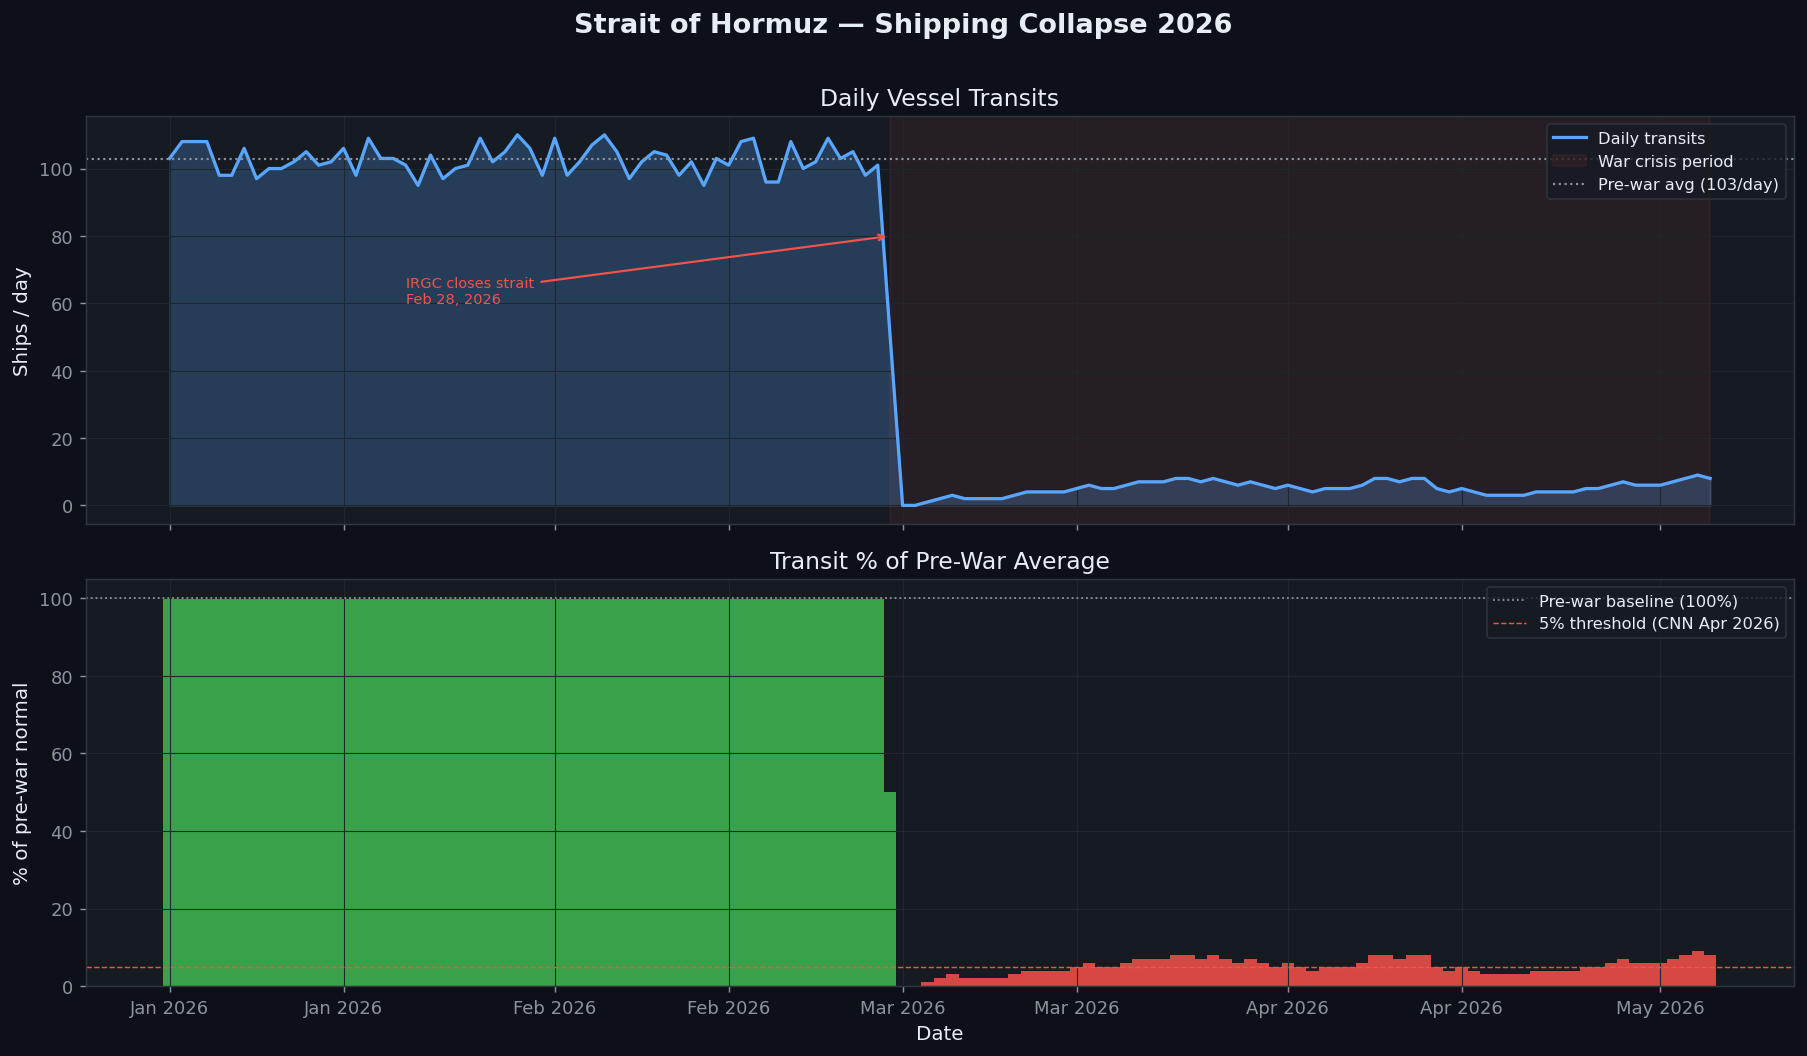

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Strait of Hormuz — Shipping Collapse 2026', fontsize=15, fontweight='bold', y=1.01)

# ── Daily transits ─────────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(df['date'], df['daily_ship_transits'],
                alpha=0.25, color=C['blue'])
ax.plot(df['date'], df['daily_ship_transits'],
        color=C['blue'], lw=1.8, label='Daily transits')
ax.axvspan(pd.to_datetime('2026-02-28'), df['date'].max(),
           alpha=0.07, color=C['red'], label='War crisis period')
ax.axhline(pre['daily_ship_transits'].mean(), color=C['grey'],
           ls=':', lw=1.2, label=f"Pre-war avg ({pre['daily_ship_transits'].mean():.0f}/day)")
ax.set_ylabel('Ships / day')
ax.set_title('Daily Vessel Transits')
ax.legend(loc='upper right')
ax.annotate('IRGC closes strait\nFeb 28, 2026',
            xy=(pd.to_datetime('2026-02-28'), 80),
            xytext=(pd.to_datetime('2026-01-20'), 60),
            arrowprops=dict(arrowstyle='->', color=C['red'], lw=1.2),
            color=C['red'], fontsize=8)

# ── Transit % of pre-war ───────────────────────────────────────────────────
ax2 = axes[1]
colors = [C['green'] if v >= 50 else C['orange'] if v >= 10 else C['red']
          for v in df['transit_pct_of_prewar_avg']]
ax2.bar(df['date'], df['transit_pct_of_prewar_avg'], color=colors, width=1, alpha=0.85)
ax2.axhline(100, color=C['grey'], ls=':', lw=1, label='Pre-war baseline (100%)')
ax2.axhline(5,   color=C['red'],  ls='--', lw=0.8, label='5% threshold (CNN Apr 2026)')
ax2.set_ylabel('% of pre-war normal')
ax2.set_title('Transit % of Pre-War Average')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('shipping_collapse.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 4 · Oil Price Shock

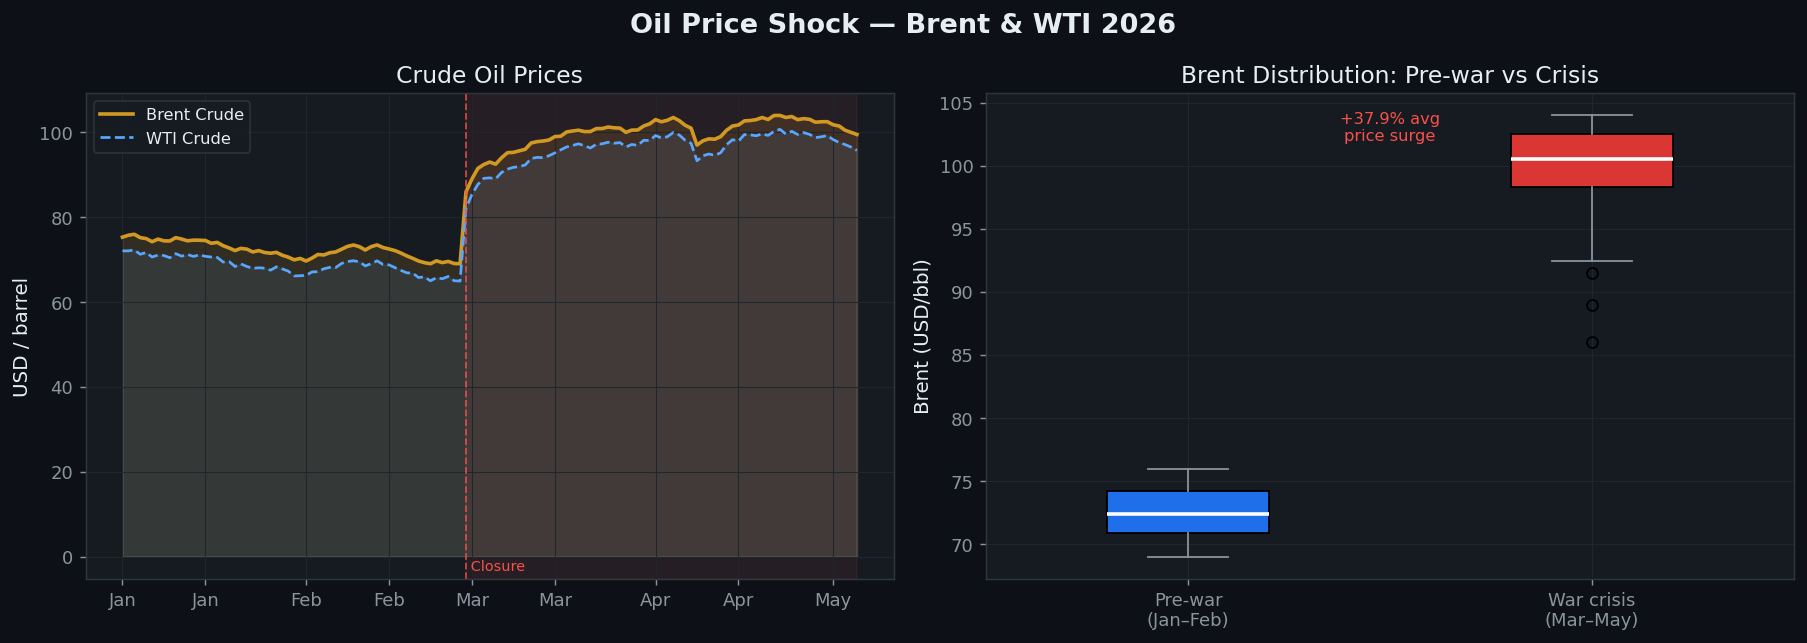

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Oil Price Shock — Brent & WTI 2026', fontsize=15, fontweight='bold')

# ── Price timeseries ───────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(df['date'], df['brent_crude_usd_bbl'], alpha=0.15, color=C['orange'])
ax.fill_between(df['date'], df['wti_crude_usd_bbl'],   alpha=0.10, color=C['blue'])
ax.plot(df['date'], df['brent_crude_usd_bbl'], color=C['orange'], lw=2,   label='Brent Crude')
ax.plot(df['date'], df['wti_crude_usd_bbl'],   color=C['blue'],   lw=1.5, label='WTI Crude', ls='--')
ax.axvspan(pd.to_datetime('2026-02-28'), df['date'].max(), alpha=0.07, color=C['red'])
ax.axvline(pd.to_datetime('2026-02-28'), color=C['red'], lw=1, ls='--', alpha=0.8)
ax.text(pd.to_datetime('2026-02-28'), ax.get_ylim()[0]+2, ' Closure', color=C['red'], fontsize=8)
ax.set_ylabel('USD / barrel')
ax.set_title('Crude Oil Prices')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend()

# ── Pre vs crisis box plot ─────────────────────────────────────────────────
ax2 = axes[1]
plot_data = [
    pre['brent_crude_usd_bbl'].values,
    war['brent_crude_usd_bbl'].values
]
bp = ax2.boxplot(plot_data, patch_artist=True, widths=0.4,
                 medianprops=dict(color='white', lw=2))
bp['boxes'][0].set_facecolor('#1f6feb')
bp['boxes'][1].set_facecolor('#da3633')
for w in bp['whiskers'] + bp['caps'] + bp['fliers']:
    w.set_color(C['grey'])
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Pre-war\n(Jan–Feb)', 'War crisis\n(Mar–May)'])
ax2.set_ylabel('Brent (USD/bbl)')
ax2.set_title('Brent Distribution: Pre-war vs Crisis')
surge = (war['brent_crude_usd_bbl'].mean() / pre['brent_crude_usd_bbl'].mean() - 1) * 100
ax2.text(1.5, war['brent_crude_usd_bbl'].max() - 2,
         f'+{surge:.1f}% avg\nprice surge',
         ha='center', fontsize=9, color=C['red'])

plt.tight_layout()
plt.savefig('oil_price_shock.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 5 · Attack Pattern Analysis

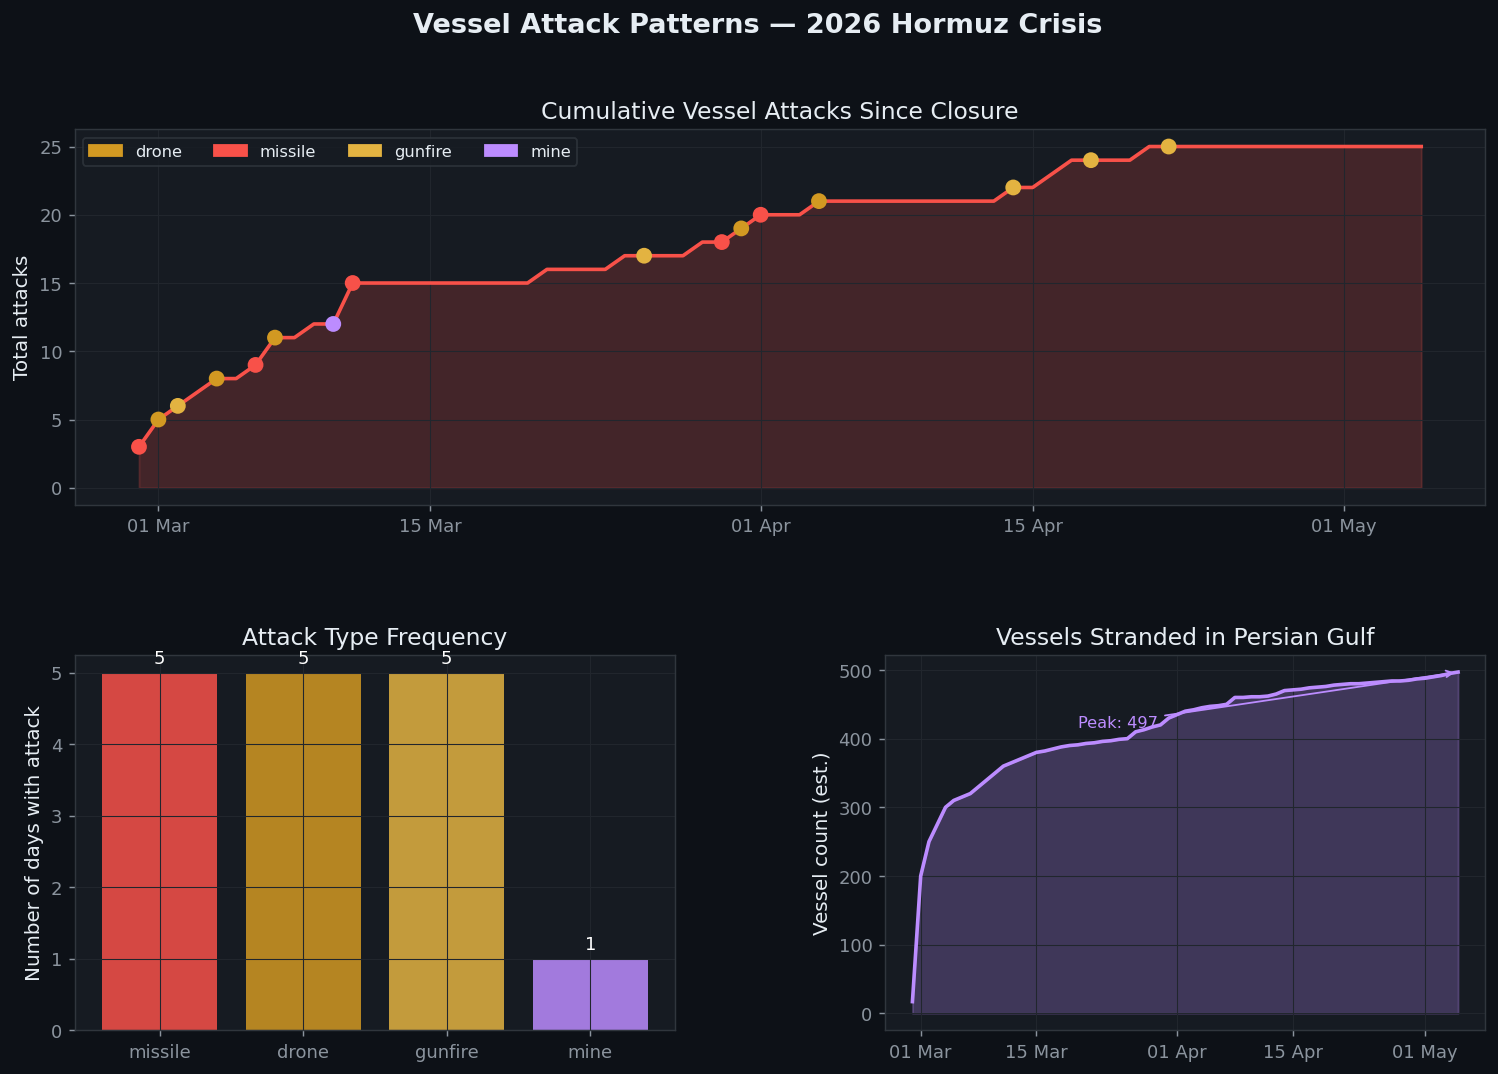

In [8]:
fig = plt.figure(figsize=(14, 9))
gs  = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Vessel Attack Patterns — 2026 Hormuz Crisis', fontsize=15, fontweight='bold')

attack_colors = {
    'none':    C['grey'],
    'drone':   C['orange'],
    'missile': C['red'],
    'gunfire': C['yellow'],
    'mine':    C['purple'],
}

# ── Cumulative attacks timeline ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(war['date'], war['vessels_attacked_cumulative'],
                 alpha=0.2, color=C['red'])
ax1.plot(war['date'], war['vessels_attacked_cumulative'],
         color=C['red'], lw=2, label='Cumulative attacks')
scatter_colors = [attack_colors[t] for t in war['attack_type']]
ax1.scatter(war[war['new_attacks_today'] > 0]['date'],
            war[war['new_attacks_today'] > 0]['vessels_attacked_cumulative'],
            c=[attack_colors[t] for t in war[war['new_attacks_today'] > 0]['attack_type']],
            s=60, zorder=5, label='Attack event')
ax1.set_title('Cumulative Vessel Attacks Since Closure')
ax1.set_ylabel('Total attacks')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
patches = [mpatches.Patch(color=v, label=k) for k, v in attack_colors.items() if k != 'none']
ax1.legend(handles=patches, loc='upper left', ncol=4)

# ── Attack type breakdown ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
type_counts = war[war['attack_type'] != 'none']['attack_type'].value_counts()
bars = ax2.bar(type_counts.index, type_counts.values,
               color=[attack_colors[t] for t in type_counts.index], alpha=0.85)
ax2.bar_label(bars, fontsize=10, color='white', padding=3)
ax2.set_title('Attack Type Frequency')
ax2.set_ylabel('Number of days with attack')

# ── Stranded vessels ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.fill_between(war['date'], war['vessels_stranded_in_gulf'],
                 alpha=0.25, color=C['purple'])
ax3.plot(war['date'], war['vessels_stranded_in_gulf'],
         color=C['purple'], lw=2)
ax3.set_title('Vessels Stranded in Persian Gulf')
ax3.set_ylabel('Vessel count (est.)')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax3.annotate(f"Peak: {war['vessels_stranded_in_gulf'].max()}",
             xy=(war.loc[war['vessels_stranded_in_gulf'].idxmax(), 'date'],
                 war['vessels_stranded_in_gulf'].max()),
             xytext=(war['date'].iloc[20], war['vessels_stranded_in_gulf'].max()-80),
             arrowprops=dict(arrowstyle='->', color=C['purple']),
             color=C['purple'], fontsize=9)

plt.savefig('attack_patterns.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 6 · Carrier Strategy Comparison

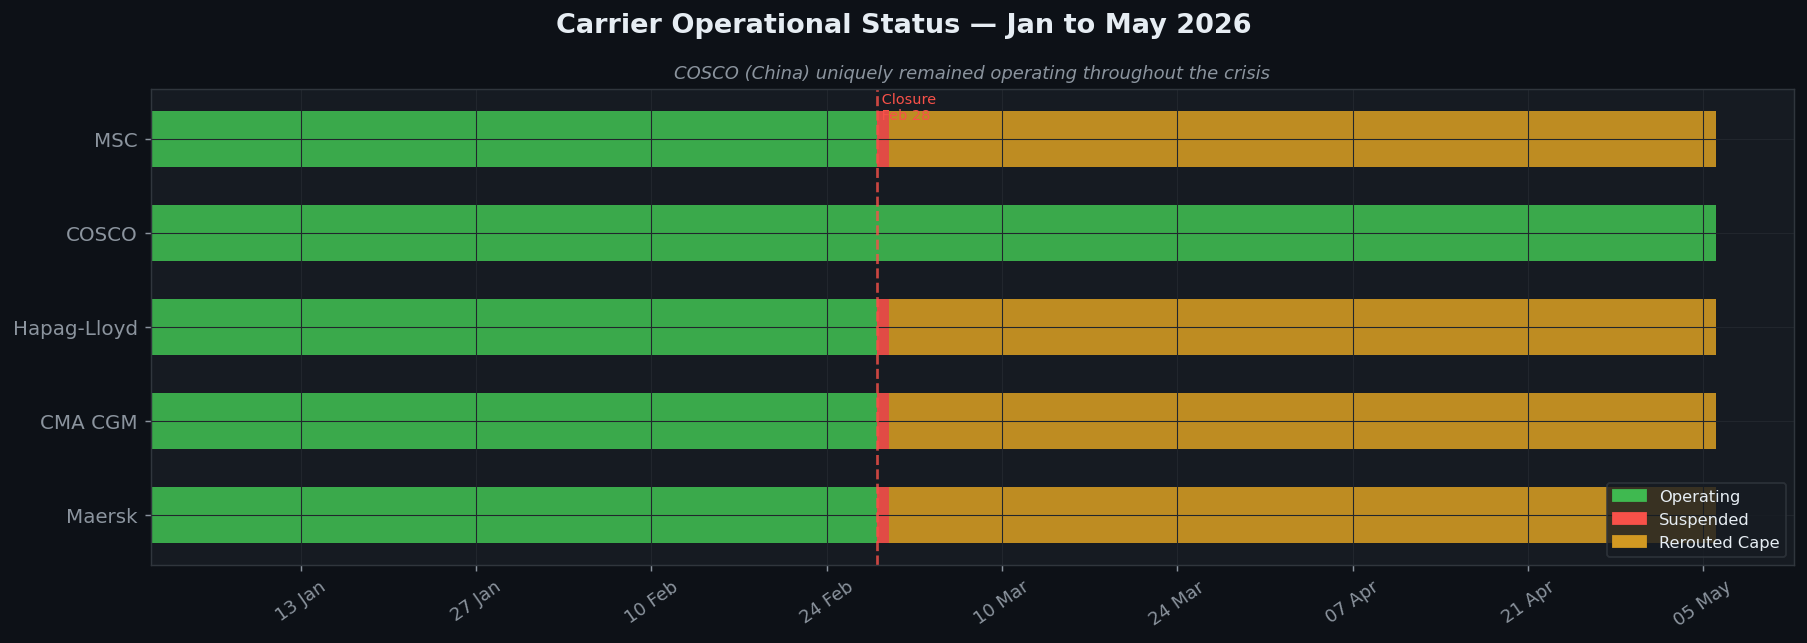

,rerouted_cape,suspended,operating
Maersk,66,1,0
CMA CGM,66,1,0
Hapag-Lloyd,66,1,0
COSCO,0,0,67
MSC,66,1,0


In [9]:
carriers = ['maersk_status', 'cma_cgm_status', 'hapag_lloyd_status', 'cosco_status', 'msc_status']
labels   = ['Maersk', 'CMA CGM', 'Hapag-Lloyd', 'COSCO', 'MSC']
status_colors = {'operating': C['green'], 'suspended': C['red'], 'rerouted_cape': C['orange']}

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Carrier Operational Status — Jan to May 2026', fontsize=15, fontweight='bold')

for i, (col, label) in enumerate(zip(carriers, labels)):
    for _, row in df.iterrows():
        ax.barh(i, 1, left=mdates.date2num(row['date']),
                color=status_colors[row[col]], height=0.6, alpha=0.9)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=35)
ax.axvline(mdates.date2num(pd.to_datetime('2026-02-28')),
           color=C['red'], lw=1.5, ls='--', alpha=0.8)
ax.text(mdates.date2num(pd.to_datetime('2026-02-28')), 4.5,
        ' Closure\n Feb 28', color=C['red'], fontsize=8, va='top')

patches = [mpatches.Patch(color=v, label=k.replace('_', ' ').title())
           for k, v in status_colors.items()]
ax.legend(handles=patches, loc='lower right')
ax.set_title('COSCO (China) uniquely remained operating throughout the crisis', fontsize=10,
             color=C['grey'], style='italic')

plt.tight_layout()
plt.savefig('carrier_strategy.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Summary table
status_summary = {}
for col, label in zip(carriers, labels):
    vc = war[col].value_counts()
    status_summary[label] = vc.to_dict()

pd.DataFrame(status_summary).T.fillna(0).astype(int)\
  .style.background_gradient(cmap='RdYlGn', axis=1)\
  .set_caption('Crisis-period days by carrier status')

## 7 · Economic Ripple — Insurance, Rerouting & Diesel

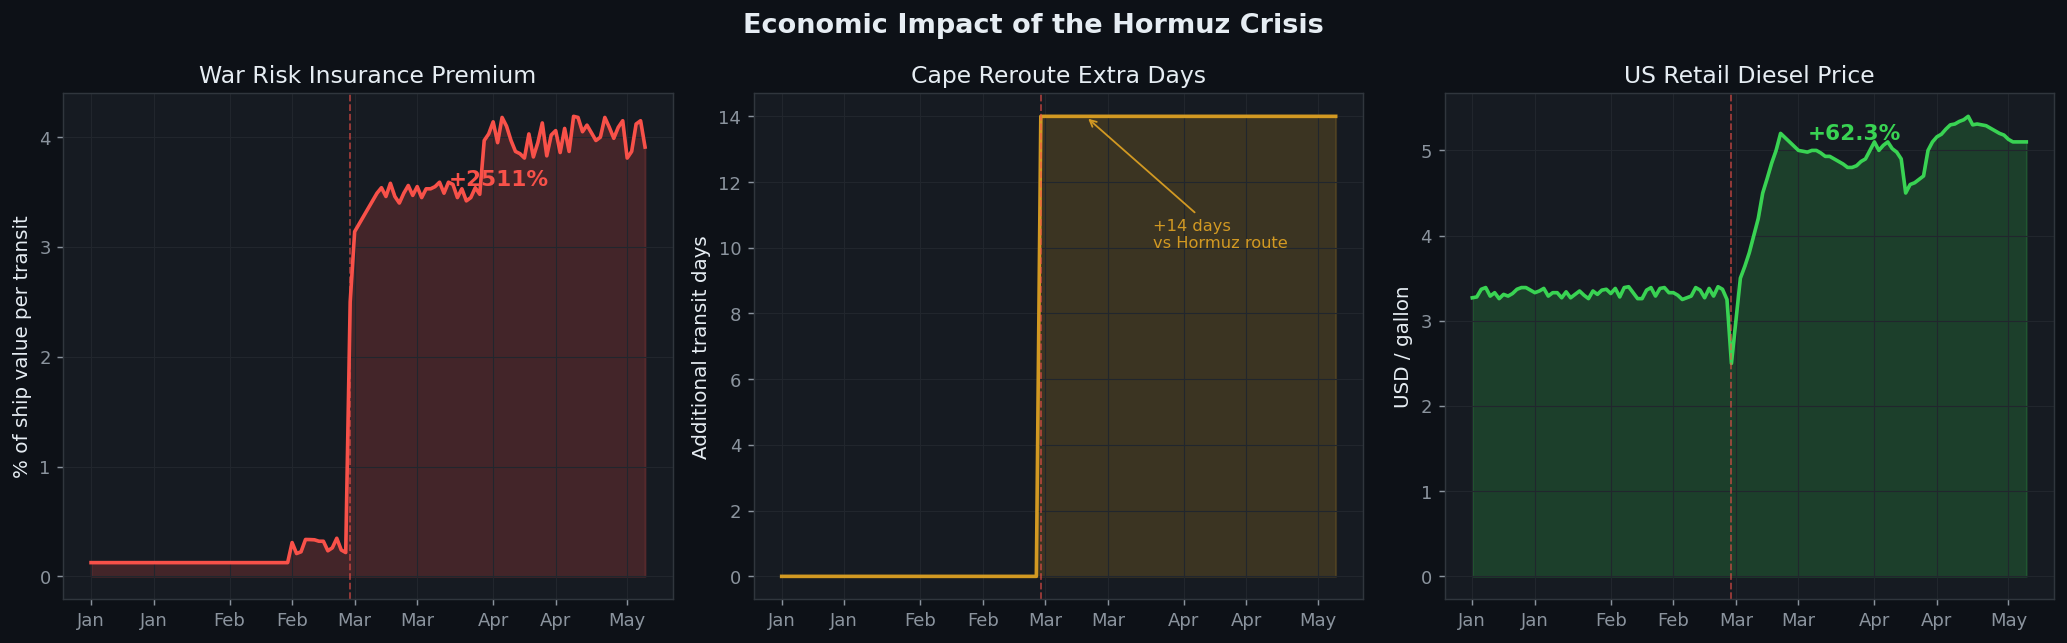

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Economic Impact of the Hormuz Crisis', fontsize=15, fontweight='bold')

# ── War risk insurance ─────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(df['date'], df['war_risk_insurance_pct'], alpha=0.2, color=C['red'])
ax.plot(df['date'], df['war_risk_insurance_pct'], color=C['red'], lw=2)
ax.axvline(pd.to_datetime('2026-02-28'), color=C['red'], lw=1, ls='--', alpha=0.6)
ax.set_title('War Risk Insurance Premium')
ax.set_ylabel('% of ship value per transit')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
surge = (war['war_risk_insurance_pct'].max() / pre['war_risk_insurance_pct'].mean() - 1) * 100
ax.text(df['date'].iloc[80], war['war_risk_insurance_pct'].max()*0.85,
        f'+{surge:.0f}%', color=C['red'], fontsize=12, fontweight='bold')

# ── Cape reroute extra days ────────────────────────────────────────────────
ax2 = axes[1]
ax2.fill_between(df['date'], df['cape_reroute_extra_days'], alpha=0.2, color=C['orange'])
ax2.plot(df['date'], df['cape_reroute_extra_days'], color=C['orange'], lw=2)
ax2.axvline(pd.to_datetime('2026-02-28'), color=C['red'], lw=1, ls='--', alpha=0.6)
ax2.set_title('Cape Reroute Extra Days')
ax2.set_ylabel('Additional transit days')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.annotate(f"+{war['cape_reroute_extra_days'].max()} days\nvs Hormuz route",
             xy=(war['date'].iloc[10], war['cape_reroute_extra_days'].max()),
             xytext=(war['date'].iloc[25], 10),
             arrowprops=dict(arrowstyle='->', color=C['orange']),
             color=C['orange'], fontsize=9)

# ── US diesel price ────────────────────────────────────────────────────────
ax3 = axes[2]
ax3.fill_between(df['date'], df['diesel_usd_gallon_us'], alpha=0.2, color=C['teal'])
ax3.plot(df['date'], df['diesel_usd_gallon_us'], color=C['teal'], lw=2)
ax3.axvline(pd.to_datetime('2026-02-28'), color=C['red'], lw=1, ls='--', alpha=0.6)
ax3.set_title('US Retail Diesel Price')
ax3.set_ylabel('USD / gallon')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
diesel_surge = (war['diesel_usd_gallon_us'].max() / pre['diesel_usd_gallon_us'].mean() - 1) * 100
ax3.text(df['date'].iloc[75], war['diesel_usd_gallon_us'].max()*0.95,
         f'+{diesel_surge:.1f}%', color=C['teal'], fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('economic_impact.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 8 · Key Events Timeline

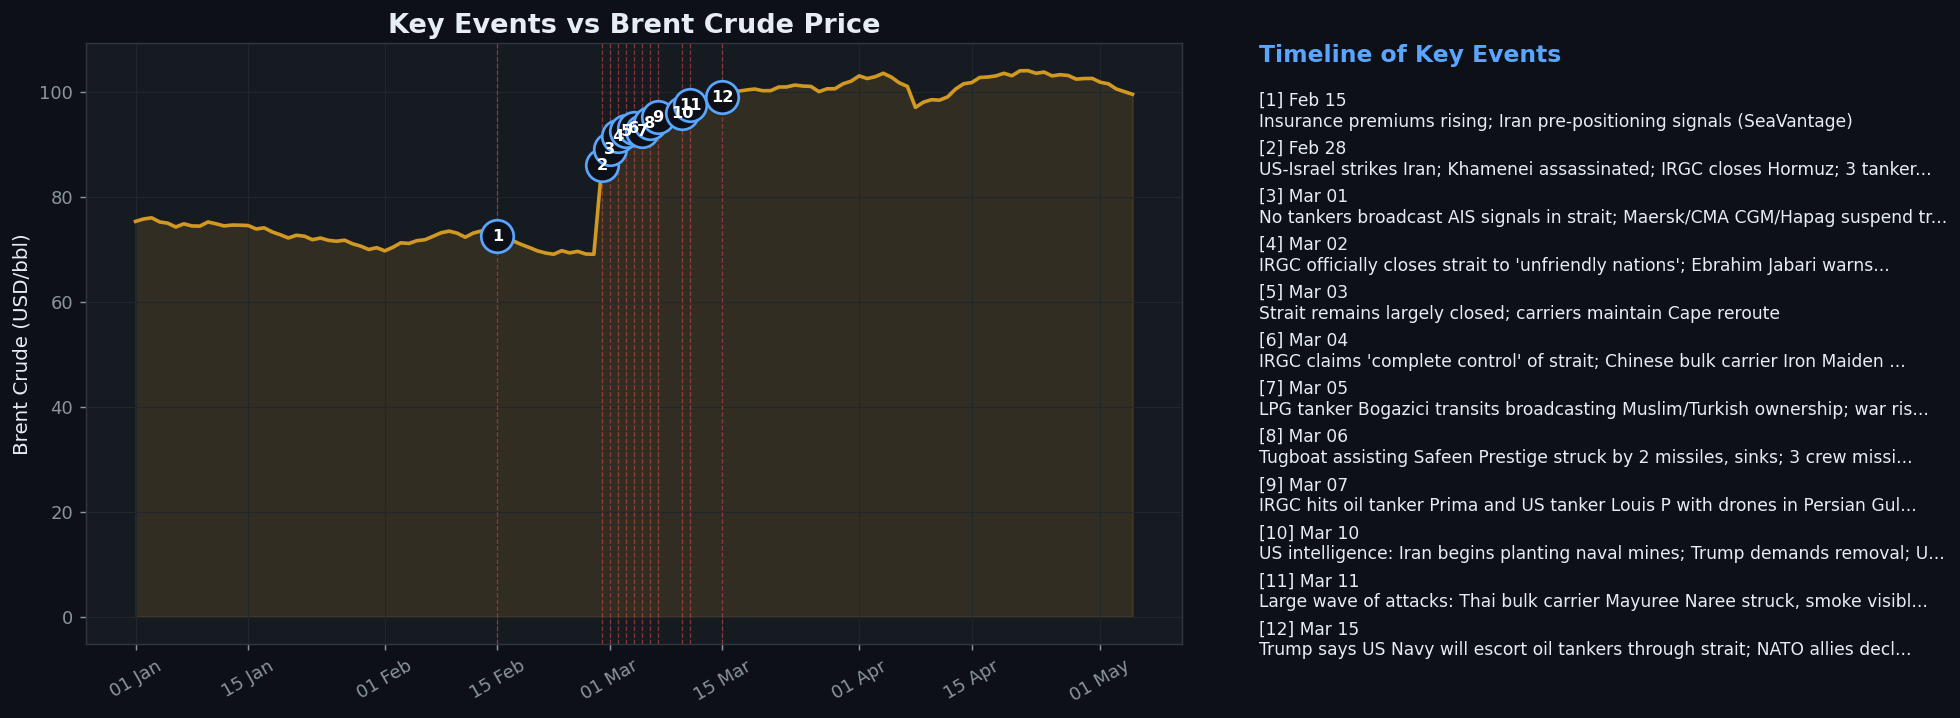

In [11]:
key_events = df[df['key_event'] != 'Normal operations'][['date', 'key_event', 'brent_crude_usd_bbl']].copy()
key_events = key_events.drop_duplicates(subset='key_event').head(12)

# Create a figure with two columns: one for the plot, one for the text legend
fig = plt.figure(figsize=(16, 6))
gs = GridSpec(1, 2, width_ratios=[2.5, 1], wspace=0.1)

# ── 1. The Main Plot ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0])
ax.set_title('Key Events vs Brent Crude Price', fontsize=15, fontweight='bold')

ax.fill_between(df['date'], df['brent_crude_usd_bbl'], alpha=0.15, color=C['orange'])
ax.plot(df['date'], df['brent_crude_usd_bbl'], color=C['orange'], lw=2)

# Add numbered markers
for i, (_, ev) in enumerate(key_events.iterrows()):
    num = i + 1
    # Vertical line
    ax.axvline(ev['date'], color=C['red'], lw=0.7, ls='--', alpha=0.5)

    # Draw a blue circle with the number inside
    ax.plot(ev['date'], ev['brent_crude_usd_bbl'], marker='o', markersize=18,
            color='#0d1117', markeredgecolor='#58a6ff', markeredgewidth=1.5, zorder=5)
    ax.text(ev['date'], ev['brent_crude_usd_bbl'], str(num),
            color='#ffffff', fontsize=9, fontweight='bold', ha='center', va='center', zorder=6)

ax.set_ylabel('Brent Crude (USD/bbl)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.tick_params(axis='x', rotation=30)

# ── 2. The Text Legend on the Right ────────────────────────────────────────
ax_leg = fig.add_subplot(gs[1])
ax_leg.axis('off') # Hide axes

ax_leg.text(0, 1.0, "Timeline of Key Events", color='#58a6ff', fontsize=13, fontweight='bold', va='top')

# Print each event in a list format
for i, (_, ev) in enumerate(key_events.iterrows()):
    num = i + 1
    date_str = ev['date'].strftime('%b %d')
    # Truncate text if it's exceptionally long
    event_desc = ev['key_event'][:75] + ('...' if len(ev['key_event']) > 75 else '')

    text_block = f"[{num}] {date_str}\n{event_desc}"
    ax_leg.text(0, 0.92 - (i * 0.08), text_block,
                color='#e6edf3', fontsize=9.5, va='top', ha='left')

plt.tight_layout()
plt.savefig('events_timeline_numbered.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 9 · Correlation Heatmap

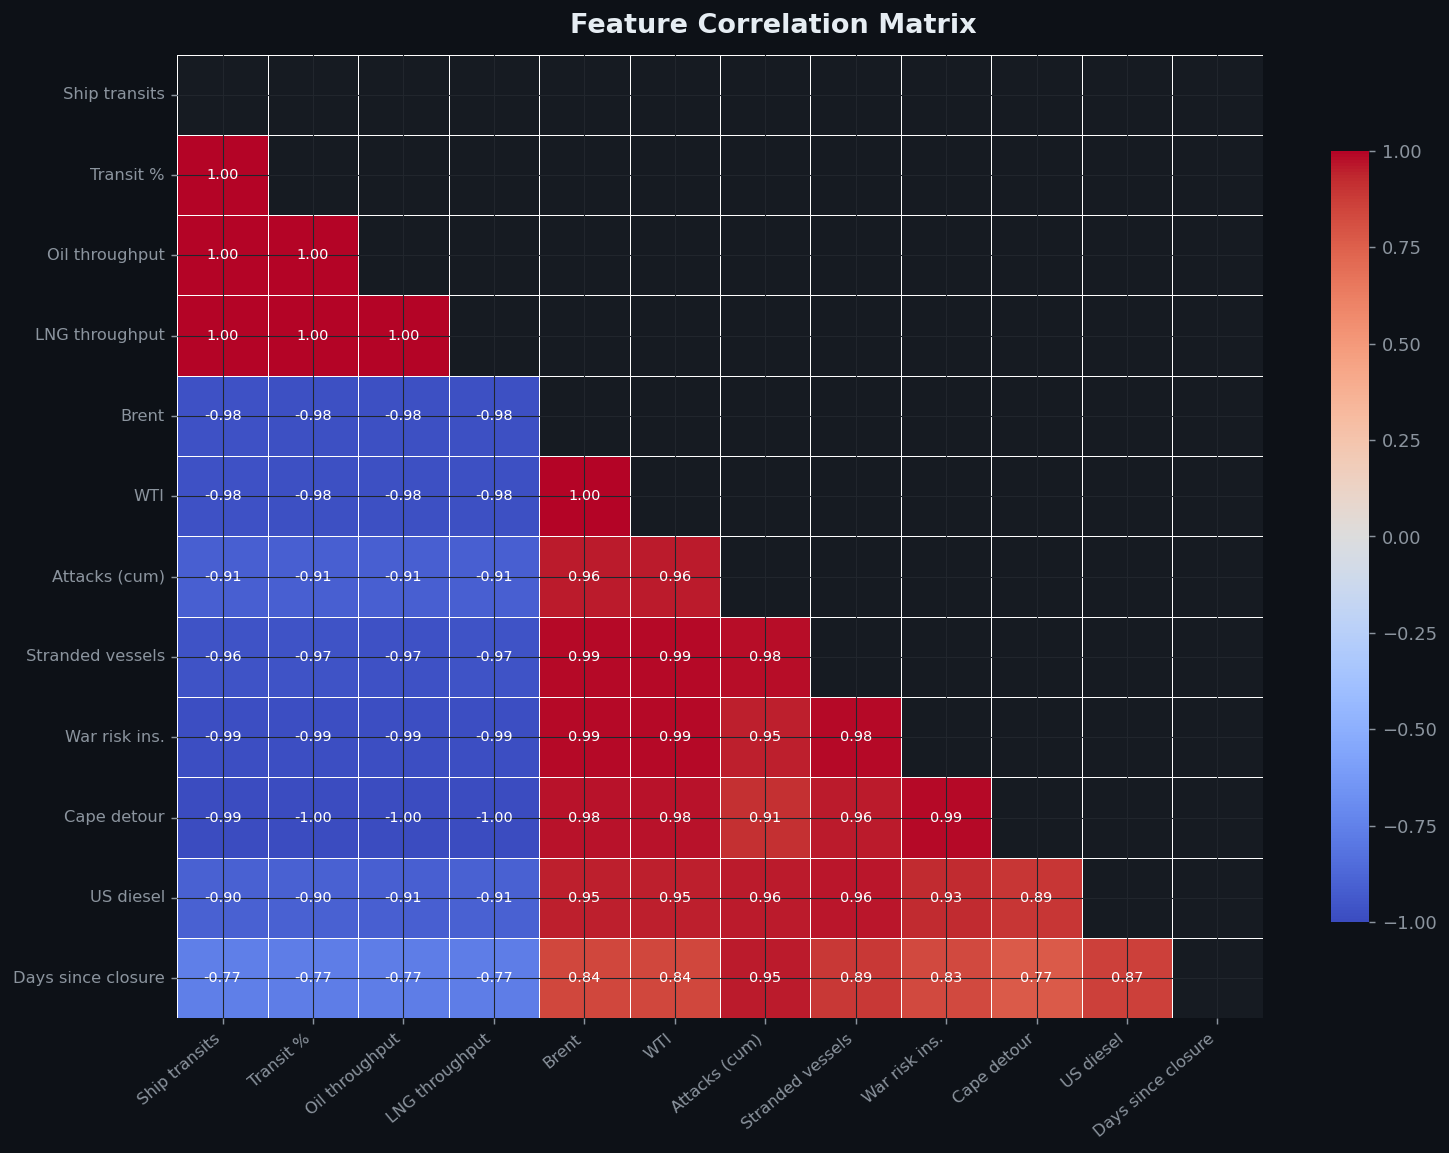

Top positive correlations:
Brent           WTI               0.999851
Transit %       Oil throughput    0.999640
                LNG throughput    0.999629
Oil throughput  LNG throughput    0.999400
Ship transits   Transit %         0.998244

Top negative correlations:
Oil throughput  War risk ins.   -0.991387
Ship transits   Cape detour     -0.994383
LNG throughput  Cape detour     -0.995820
Transit %       Cape detour     -0.995906
Oil throughput  Cape detour     -0.995915


In [12]:
num_cols = [
    'daily_ship_transits', 'transit_pct_of_prewar_avg',
    'oil_throughput_mbpd', 'lng_throughput_bcfd',
    'brent_crude_usd_bbl', 'wti_crude_usd_bbl',
    'vessels_attacked_cumulative', 'vessels_stranded_in_gulf',
    'war_risk_insurance_pct', 'cape_reroute_extra_days',
    'diesel_usd_gallon_us', 'days_since_closure'
]

corr = df[num_cols].corr()
short = [
    'Ship transits', 'Transit %', 'Oil throughput', 'LNG throughput',
    'Brent', 'WTI', 'Attacks (cum)', 'Stranded vessels',
    'War risk ins.', 'Cape detour', 'US diesel', 'Days since closure'
]
corr.index   = short
corr.columns = short

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle('Feature Correlation Matrix', fontsize=15, fontweight='bold')

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', linewidths=0.4,
            cmap='coolwarm', vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('Top positive correlations:')
corr_flat = corr.unstack().drop_duplicates().sort_values(ascending=False)
corr_flat = corr_flat[corr_flat < 0.9999]
print(corr_flat.head(5).to_string())
print('\nTop negative correlations:')
print(corr_flat.tail(5).to_string())

## 10 · Summary Statistics

In [13]:
stats = df[num_cols].describe().T
stats.index = short

stats.style\
    .format('{:.2f}')\
    .background_gradient(subset=['mean'], cmap='Blues')\
    .background_gradient(subset=['std'],  cmap='Oranges')\
    .set_caption('📊 Full Numeric Summary')\
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size','15px'),('font-weight','bold')]
    },{
        'selector': 'th',
        'props': [('background-color','#21262d'),('color','#58a6ff'),
                  ('font-size','11px')]
    },{
        'selector': 'td',
        'props': [('font-size','11px'),('border','1px solid #30363d')]
    }])

,count,mean,std,min,25%,50%,75%,max
Ship transits,125.00,50.74,48.80,0.00,5.00,8.00,102.00,110.00
Transit %,125.00,49.50,47.37,0.00,5.00,8.00,100.00,100.00
Oil throughput,125.00,9.93,9.42,0.80,1.00,1.60,19.90,20.50
LNG throughput,125.00,5.18,4.96,0.30,0.50,0.80,10.40,10.80
Brent,125.00,87.04,14.05,69.02,72.50,92.50,100.90,104.00
WTI,125.00,83.40,14.11,64.94,68.85,89.16,97.30,100.72
Attacks (cum),125.00,9.90,10.18,0.00,0.00,8.00,21.00,25.00
Stranded vessels,125.00,221.93,215.84,0.00,0.00,300.00,445.00,497.00
War risk ins.,125.00,2.09,1.82,0.12,0.12,3.35,3.86,4.19
Cape detour,125.00,7.50,7.01,0.00,0.00,14.00,14.00,14.00


---
## Key Findings

| # | Finding |
|---|---|
| 1 | Ship transits collapsed **−94.4%** within days of closure (103/day → 5.8/day crisis avg) |
| 2 | Brent crude surged **+43.7%** from pre-war avg to crisis peak |
| 3 | War risk insurance exploded **+2,511%** — making many voyages economically unviable |
| 4 | **COSCO (China)** uniquely stayed operational — Iran granted passage to friendly nations |
| 5 | 490+ vessels became stranded inside the Persian Gulf with no exit |
| 6 | Drone attacks were the most frequent weapon type; mines caused the most fear |
| 7 | US diesel prices rose **+116%** — demonstrating downstream consumer impact |
| 8 | Strong negative correlation (≈ −0.99) between ship transits and Cape detours/days since closure |

---
*Dataset: Hormuz Shipping Crisis 2026 | CC BY 4.0*